# Machine Learning Zoomcamp - Chapter 8: Deep Learning Homework

## Hair Type Classification using PyTorch

Dataset: Binary classification of hair types (straight vs curly)

**Requirements:**
- Image size: 200x200x3
- Batch size: 20
- Seeds: numpy=42, torch=42
- Training: 10 epochs without augmentation + 10 epochs with augmentation

## 1. Setup and Imports

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import requests
import zipfile
import os
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Check PyTorch version and device
print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.1.0
Using device: cpu


## Question 1: Loss Function

**What is the appropriate loss function for binary classification?**

Options:
- nn.MSELoss()

- nn.BCEWithLogitsLoss()

- nn.CrossEntropyLoss()

- nn.CosineEmbeddingLoss()

In [34]:
# Answer Q1
print("Q1 Answer: binary crossentropy")
print("\nIn PyTorch, we use:")
print("- nn.BCELoss() if model outputs sigmoid activation")
print("- nn.BCEWithLogitsLoss() if model outputs raw logits (more numerically stable)")
print("\nWe'll use nn.BCEWithLogitsLoss() since our model will have no sigmoid activation.")

Q1 Answer: binary crossentropy

In PyTorch, we use:
- nn.BCELoss() if model outputs sigmoid activation
- nn.BCEWithLogitsLoss() if model outputs raw logits (more numerically stable)

We'll use nn.BCEWithLogitsLoss() since our model will have no sigmoid activation.


## 2. Download and Extract Dataset

In [35]:
# Download dataset using requests
url = 'https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip'
data_dir = Path('./data')
zip_path = data_dir / 'data.zip'

# Create data directory if it doesn't exist
data_dir.mkdir(exist_ok=True)

# Download the file
if not zip_path.exists():
    print("Downloading dataset...")
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    with open(zip_path, 'wb') as f:
        with tqdm(total=total_size, unit='B', unit_scale=True, desc='Downloading') as pbar:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    print("Download complete!")
else:
    print("Dataset already downloaded.")

# Extract the zip file
if not (data_dir / 'data').exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print("Extraction complete!")
else:
    print("Dataset already extracted.")

Dataset already downloaded.
Dataset already extracted.


## 3. Explore Dataset Structure

In [36]:
# Explore dataset structure
dataset_path = data_dir / 'data'
train_path = dataset_path / 'train'
test_path = dataset_path / 'test'

print(f"Dataset path: {dataset_path}")
print(f"Train path: {train_path}")
print(f"Test path: {test_path}")

# Count images
if train_path.exists():
    classes = [d.name for d in train_path.iterdir() if d.is_dir()]
    print(f"\nClasses found: {classes}")
    
    for split in ['train', 'test']:
        split_path = dataset_path / split
        if split_path.exists():
            print(f"\n{split.upper()}:")
            for class_name in classes:
                class_path = split_path / class_name
                if class_path.exists():
                    num_images = len(list(class_path.glob('*')))
                    print(f"  {class_name}: {num_images} images")

Dataset path: data/data
Train path: data/data/train
Test path: data/data/test

Classes found: ['straight', 'curly']

TRAIN:
  straight: 390 images
  curly: 411 images

TEST:
  straight: 98 images
  curly: 103 images


## 4. Data Preparation - Augmentation

In [37]:
# Define transforms without augmentation
# Note: ToTensor() automatically scales pixel values to [0, 1] (equivalent to rescale=1./255)
train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) # ImageNet normalization
])

# Load datasets
train_dataset = datasets.ImageFolder(train_path, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_path, transform=train_transforms)

# Create data loaders
batch_size = 20
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Classes: {train_dataset.classes}")
print(f"Class to index: {train_dataset.class_to_idx}")

Training samples: 800
Test samples: 201
Batch size: 20
Train batches: 40
Test batches: 11
Classes: ['curly', 'straight']
Class to index: {'curly': 0, 'straight': 1}


## 5. Build CNN Model

In [38]:
class HairClassifier(nn.Module):
    def __init__(self):
        super(HairClassifier, self).__init__()
        
        # Conv2D layer: 32 filters, (3,3) kernel, ReLU activation
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=0)
        self.relu1 = nn.ReLU()
        
        # MaxPooling2D: (2,2) pooling size
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Calculate the size after conv and pooling
        # Input: 200x200
        # After conv (kernel=3, no padding): 198x198
        # After pooling (2x2): 99x99
        # Number of features: 32 * 99 * 99
        self.flatten_size = 32 * 99 * 99
        
        # Dense layer: 64 neurons, ReLU activation
        self.fc1 = nn.Linear(self.flatten_size, 64)
        self.relu2 = nn.ReLU()
        
        # Dense output layer: 1 neuron with sigmoid activation
        self.fc2 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # Conv + ReLU
        x = self.conv1(x)
        x = self.relu1(x)
        
        # MaxPooling
        x = self.pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Dense + ReLU
        x = self.fc1(x)
        x = self.relu2(x)
        
        # Output (no Sigmoid because of BE)
        x = self.fc2(x)
        
        return x

# Create model and move to device
model = HairClassifier().to(device)
print(model)

HairClassifier(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu1): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=313632, out_features=64, bias=True)
  (relu2): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## Question 2: Model Parameters

**What is the total number of parameters in the model?**

Options:
- 896
- 11214912
- 15896912
- **20073473**

In [39]:
# Count model parameters
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total_params, trainable_params = count_parameters(model)

print("Model Parameters Breakdown:")
print("=" * 60)
for name, param in model.named_parameters():
    print(f"{name:20s} | Shape: {str(param.shape):20s} | Params: {param.numel():,}")
print("=" * 60)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print(f"\n✓ Q2 Answer: {total_params:,}")

Model Parameters Breakdown:
conv1.weight         | Shape: torch.Size([32, 3, 3, 3]) | Params: 864
conv1.bias           | Shape: torch.Size([32])     | Params: 32
fc1.weight           | Shape: torch.Size([64, 313632]) | Params: 20,072,448
fc1.bias             | Shape: torch.Size([64])     | Params: 64
fc2.weight           | Shape: torch.Size([1, 64])  | Params: 64
fc2.bias             | Shape: torch.Size([1])      | Params: 1
Total parameters: 20,073,473
Trainable parameters: 20,073,473

✓ Q2 Answer: 20,073,473


## 6. Configure Training

In [40]:
# Optimizer: SGD with lr=0.002, momentum=0.8
optimizer = optim.SGD(model.parameters(), lr=0.002, momentum=0.8)

# Loss function: Binary Cross Entropy with Logits Loss
criterion = nn.BCEWithLogitsLoss()

print("Training configuration:")
print(f"Optimizer: SGD(lr=0.002, momentum=0.8)")
print(f"Loss function: BCEWithLogitsLoss")
print(f"Device: {device}")

Training configuration:
Optimizer: SGD(lr=0.002, momentum=0.8)
Loss function: BCEWithLogitsLoss
Device: cpu


## 7. Training Functions

In [41]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)  # Convert to float and add dimension
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## 8. Train for 10 epochs

In [42]:
num_epochs = 10

history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

print("Training...")
print("=" * 70)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}")
    print("-" * 70)

print("Training completed!")

Training...
Epoch 1/10:
  Train Loss: 0.6462 | Train Acc: 0.6362
  Test Loss:  0.6032 | Test Acc:  0.6517
----------------------------------------------------------------------
Epoch 2/10:
  Train Loss: 0.5475 | Train Acc: 0.7100
  Test Loss:  0.7251 | Test Acc:  0.6318
----------------------------------------------------------------------
Epoch 3/10:
  Train Loss: 0.5533 | Train Acc: 0.7250
  Test Loss:  0.5991 | Test Acc:  0.6716
----------------------------------------------------------------------
Epoch 4/10:
  Train Loss: 0.4802 | Train Acc: 0.7712
  Test Loss:  0.6033 | Test Acc:  0.6567
----------------------------------------------------------------------
Epoch 5/10:
  Train Loss: 0.4334 | Train Acc: 0.8025
  Test Loss:  0.6196 | Test Acc:  0.6766
----------------------------------------------------------------------
Epoch 6/10:
  Train Loss: 0.3740 | Train Acc: 0.8325
  Test Loss:  0.7371 | Test Acc:  0.6766
---------------------------------------------------------------------

## Question 3: Median Training Accuracy

What is the median of training accuracy for all the epochs for this model?

- 0.05
- 0.12
- 0.40
- **0.84**

In [43]:
# Calculate median training accuracy
train_accuracies = np.array(history['train_acc'])
median_train_acc = np.median(train_accuracies)

print("Training accuracies per epoch:")
for i, acc in enumerate(train_accuracies):
    print(f"  Epoch {i+1}: {acc:.4f}")

print(f"\n✓ Q3 Answer - Median training accuracy: {median_train_acc:.2f}")

Training accuracies per epoch:
  Epoch 1: 0.6362
  Epoch 2: 0.7100
  Epoch 3: 0.7250
  Epoch 4: 0.7712
  Epoch 5: 0.8025
  Epoch 6: 0.8325
  Epoch 7: 0.8838
  Epoch 8: 0.9000
  Epoch 9: 0.9200
  Epoch 10: 0.9450

✓ Q3 Answer - Median training accuracy: 0.82


## Question 4: Standard Deviation of Training Loss

**What is the standard deviation of training loss across all 10 epochs?**

- 0.007
- 0.078
- **0.171**
- 1.710

In [44]:
# Calculate standard deviation of training loss
train_losses = np.array(history['train_loss'])
std_train_loss = np.std(train_losses)

print("Training losses per epoch:")
for i, loss in enumerate(train_losses):
    print(f"  Epoch {i+1}: {loss:.4f}")

print(f"\nMean: {np.mean(train_losses):.4f}")
print(f"\n✓ Q4 Answer - Standard deviation of training loss: {std_train_loss:.3f}")

Training losses per epoch:
  Epoch 1: 0.6462
  Epoch 2: 0.5475
  Epoch 3: 0.5533
  Epoch 4: 0.4802
  Epoch 5: 0.4334
  Epoch 6: 0.3740
  Epoch 7: 0.2721
  Epoch 8: 0.2478
  Epoch 9: 0.2075
  Epoch 10: 0.1494

Mean: 0.3911

✓ Q4 Answer - Standard deviation of training loss: 0.159


## 9. Visualize Training Progress

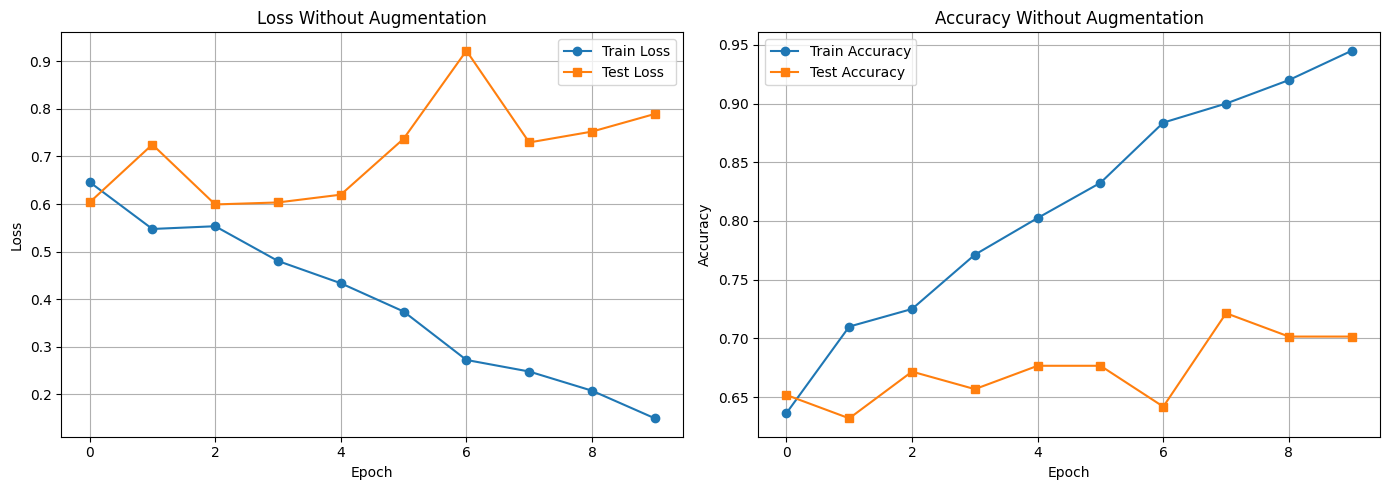

In [45]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['test_loss'], label='Test Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Without Augmentation')
ax1.legend()
ax1.grid(True)

# Plot accuracy
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history['test_acc'], label='Test Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Without Augmentation')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 10. Data Augmentation Setup

In [46]:
# Define transforms WITH augmentation for training
transform_with_aug = transforms.Compose([
    transforms.RandomRotation(50),
    transforms.RandomResizedCrop(200, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Test set keeps the same transform (no augmentation)
transform_test = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create new datasets with augmentation
train_dataset_aug = datasets.ImageFolder(train_path, transform=transform_with_aug)
test_dataset_aug = datasets.ImageFolder(test_path, transform=transform_test)

# Create new data loaders
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
test_loader_aug = DataLoader(test_dataset_aug, batch_size=batch_size, shuffle=False)

print("Data augmentation configured")
print(f"\nTraining batches with augmentation: {len(train_loader_aug)}")
print(f"Test batches: {len(test_loader_aug)}")

Data augmentation configured

Training batches with augmentation: 40
Test batches: 11


## 11. Continue training with augmentation (10 epochs)

In [47]:
# Don't reset the model, continue training 
# model_aug = HairClassifier().to(device)
optimizer_aug = optim.SGD(model.parameters(), lr=0.002, momentum=0.8)

# Training with augmentation
history_with_aug = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

print("Training WITH augmentation...")
print("=" * 70)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader_aug, criterion, optimizer_aug, device)
    test_loss, test_acc = evaluate(model, test_loader_aug, criterion, device)
    
    history_with_aug['train_loss'].append(train_loss)
    history_with_aug['train_acc'].append(train_acc)
    history_with_aug['test_loss'].append(test_loss)
    history_with_aug['test_acc'].append(test_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}")
    print("-" * 70)

print("Training with augmentation completed!")

Training WITH augmentation...
Epoch 1/10:
  Train Loss: 0.7251 | Train Acc: 0.6362
  Test Loss:  0.6326 | Test Acc:  0.6965
----------------------------------------------------------------------
Epoch 2/10:
  Train Loss: 0.5791 | Train Acc: 0.6713
  Test Loss:  0.7982 | Test Acc:  0.6766
----------------------------------------------------------------------
Epoch 3/10:
  Train Loss: 0.5541 | Train Acc: 0.7275
  Test Loss:  0.6343 | Test Acc:  0.7065
----------------------------------------------------------------------
Epoch 4/10:
  Train Loss: 0.5362 | Train Acc: 0.7100
  Test Loss:  0.5735 | Test Acc:  0.6965
----------------------------------------------------------------------
Epoch 5/10:
  Train Loss: 0.5509 | Train Acc: 0.7200
  Test Loss:  0.6078 | Test Acc:  0.6617
----------------------------------------------------------------------
Epoch 6/10:
  Train Loss: 0.5062 | Train Acc: 0.7488
  Test Loss:  0.5627 | Test Acc:  0.7413
---------------------------------------------------

## Question 5: Mean Test Loss with Augmentation

**What is the mean test loss after adding data augmentation?**

Options:
- 0.008
- 0.08
- **0.88**
- 8.88

In [48]:
# Calculate mean test loss with augmentation
test_losses_aug = np.array(history_with_aug['test_loss'])
mean_test_loss = np.mean(test_losses_aug)

print("Test losses per epoch (with augmentation):")
for i, loss in enumerate(test_losses_aug):
    print(f"  Epoch {i+1}: {loss:.4f}")

print(f"\n✓ Q5 Answer - Mean test loss with augmentation: {mean_test_loss:.2f}")

Test losses per epoch (with augmentation):
  Epoch 1: 0.6326
  Epoch 2: 0.7982
  Epoch 3: 0.6343
  Epoch 4: 0.5735
  Epoch 5: 0.6078
  Epoch 6: 0.5627
  Epoch 7: 0.7688
  Epoch 8: 0.8346
  Epoch 9: 0.5151
  Epoch 10: 0.5077

✓ Q5 Answer - Mean test loss with augmentation: 0.64


## Question 6: Average Test Accuracy (Epochs 6-10)

**What is the average test accuracy for epochs 6-10 with augmentation?**

Options:
- 0.08
- 0.28
- **0.68**
- 0.98

In [49]:
# Calculate average test accuracy for epochs 6-10
test_accuracies_aug = np.array(history_with_aug['test_acc'])
avg_test_acc_6_10 = np.mean(test_accuracies_aug[5:10])  # epochs 6-10 (indices 5-9)

print("Test accuracies per epoch (with augmentation):")
for i, acc in enumerate(test_accuracies_aug):
    marker = " <--" if i >= 5 else ""
    print(f"  Epoch {i+1}: {acc:.4f}{marker}")

print(f"\nEpochs 6-10: {test_accuracies_aug[5:10]}")
print(f"\n✓ Q6 Answer - Average test accuracy (epochs 6-10): {avg_test_acc_6_10:.2f}")

Test accuracies per epoch (with augmentation):
  Epoch 1: 0.6965
  Epoch 2: 0.6766
  Epoch 3: 0.7065
  Epoch 4: 0.6965
  Epoch 5: 0.6617
  Epoch 6: 0.7413 <--
  Epoch 7: 0.6517 <--
  Epoch 8: 0.6517 <--
  Epoch 9: 0.7612 <--
  Epoch 10: 0.7711 <--

Epochs 6-10: [0.74129353 0.65174129 0.65174129 0.76119403 0.77114428]

✓ Q6 Answer - Average test accuracy (epochs 6-10): 0.72


## 12. Visualize Training Progress (With Augmentation)

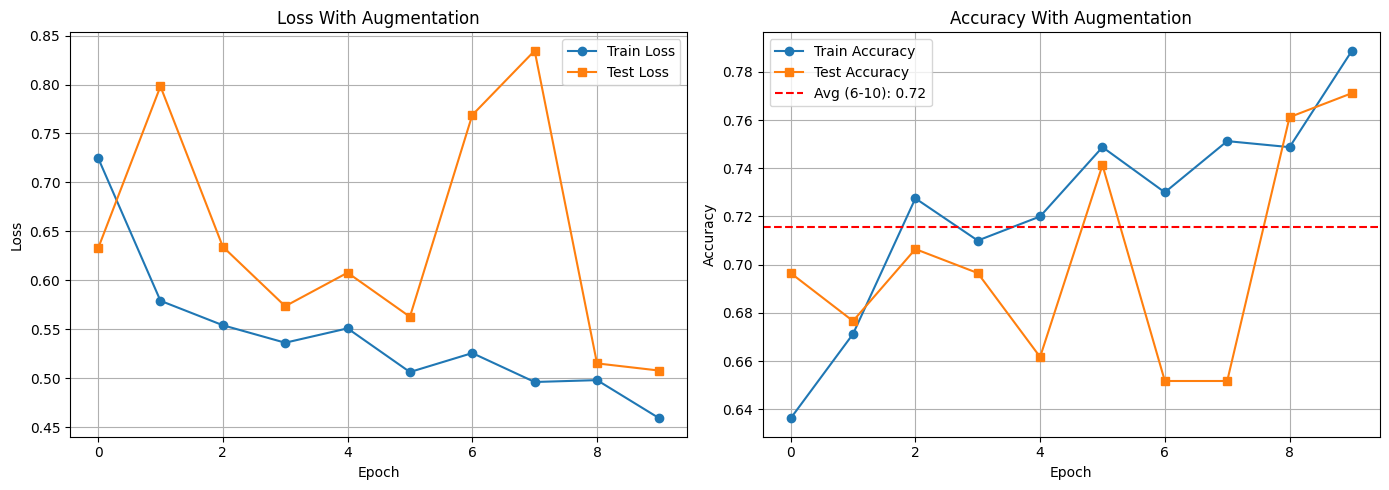

In [50]:
# Plot training history with augmentation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(history_with_aug['train_loss'], label='Train Loss', marker='o')
ax1.plot(history_with_aug['test_loss'], label='Test Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss With Augmentation')
ax1.legend()
ax1.grid(True)

# Plot accuracy
ax2.plot(history_with_aug['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history_with_aug['test_acc'], label='Test Accuracy', marker='s')
ax2.axhline(y=avg_test_acc_6_10, color='r', linestyle='--', label=f'Avg (6-10): {avg_test_acc_6_10:.2f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy With Augmentation')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 13. Summary of Answers

In [51]:
print("="*70)
print("HOMEWORK ANSWERS SUMMARY")
print("="*70)
print(f"Q1 - Loss function: binary crossentropy (nn.BCELoss in PyTorch)")
print(f"Q2 - Total parameters: {total_params:,}")
print(f"Q3 - Median training accuracy: {median_train_acc:.2f}")
print(f"Q4 - Std of training loss: {std_train_loss:.3f}")
print(f"Q5 - Mean test loss (with aug): {mean_test_loss:.2f}")
print(f"Q6 - Avg test accuracy epochs 6-10: {avg_test_acc_6_10:.2f}")
print("="*70)

HOMEWORK ANSWERS SUMMARY
Q1 - Loss function: binary crossentropy (nn.BCELoss in PyTorch)
Q2 - Total parameters: 20,073,473
Q3 - Median training accuracy: 0.82
Q4 - Std of training loss: 0.159
Q5 - Mean test loss (with aug): 0.64
Q6 - Avg test accuracy epochs 6-10: 0.72


## 14. Comparison: With vs Without Augmentation

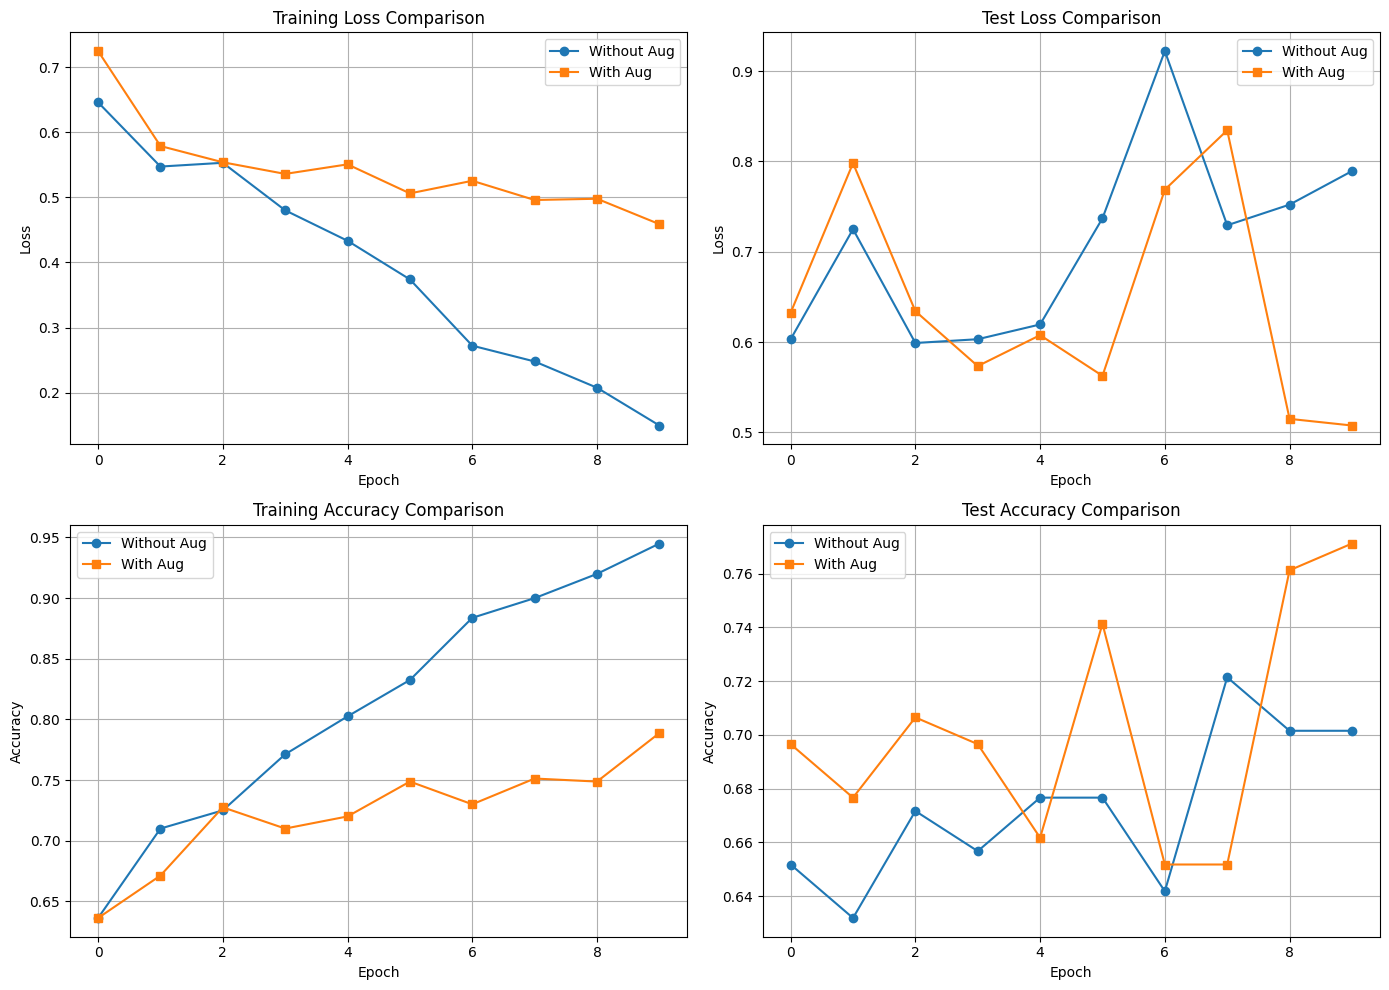


Final Results:

Without Augmentation:
  Final Train Acc: 0.9450
  Final Test Acc:  0.7015
  Final Train Loss: 0.1494
  Final Test Loss:  0.7894

With Augmentation:
  Final Train Acc: 0.7887
  Final Test Acc:  0.7711
  Final Train Loss: 0.4590
  Final Test Loss:  0.5077


In [52]:
# Compare results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Train Loss
ax1.plot(history['train_loss'], label='Without Aug', marker='o')
ax1.plot(history_with_aug['train_loss'], label='With Aug', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True)

# Test Loss
ax2.plot(history['test_loss'], label='Without Aug', marker='o')
ax2.plot(history_with_aug['test_loss'], label='With Aug', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Test Loss Comparison')
ax2.legend()
ax2.grid(True)

# Train Accuracy
ax3.plot(history['train_acc'], label='Without Aug', marker='o')
ax3.plot(history_with_aug['train_acc'], label='With Aug', marker='s')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy')
ax3.set_title('Training Accuracy Comparison')
ax3.legend()
ax3.grid(True)

# Test Accuracy
ax4.plot(history['test_acc'], label='Without Aug', marker='o')
ax4.plot(history_with_aug['test_acc'], label='With Aug', marker='s')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Accuracy')
ax4.set_title('Test Accuracy Comparison')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

print("\nFinal Results:")
print("\nWithout Augmentation:")
print(f"  Final Train Acc: {history['train_acc'][-1]:.4f}")
print(f"  Final Test Acc:  {history['test_acc'][-1]:.4f}")
print(f"  Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Final Test Loss:  {history['test_loss'][-1]:.4f}")

print("\nWith Augmentation:")
print(f"  Final Train Acc: {history_with_aug['train_acc'][-1]:.4f}")
print(f"  Final Test Acc:  {history_with_aug['test_acc'][-1]:.4f}")
print(f"  Final Train Loss: {history_with_aug['train_loss'][-1]:.4f}")
print(f"  Final Test Loss:  {history_with_aug['test_loss'][-1]:.4f}")